# Importación de librerías

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL

import glob
import cv2
!pip install split-folders
import splitfolders
import shutil

import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

from sklearn import svm
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import  accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

Cargar el dataset.

In [ ]:
from google.colab import drive, files
from google.colab.patches import cv2_imshow
drive.mount('/content/drive/')
import os
import tensorflow as tf

# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\EVENODD'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\ODD'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\EVEN'
root_dir = r'C:\Users\TU_RUTA_AL_DATASET\GROUP09'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\KAGGLE'

train_folder = os.path.join(root_dir, "train")
val_folder   = os.path.join(root_dir, "val")
test_folder  = os.path.join(root_dir, "test")

# Parámetros
batch_size= 16
img_height= 224
img_width= 224
dropout_rate = 0.5
epochs= 20
num_classes  = 6

train_ds = tf.keras.utils.image_dataset_from_directory(
  train_folder,
  seed = 123,
  image_size = (img_height, img_width),
  batch_size = batch_size,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  val_folder,
  seed=123,
  image_size=(img_height, img_width),
  batch_size = batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_folder,
    seed = 123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print(class_names)

Mounted at /content/drive/
Found 462 files belonging to 6 classes.
Found 96 files belonging to 6 classes.
Found 106 files belonging to 6 classes.
['cups', 'forks', 'glasses', 'knives', 'plates', 'spoons']


Creamos el training, validation y test dataset

Imprimir 9 imágenes del dataset

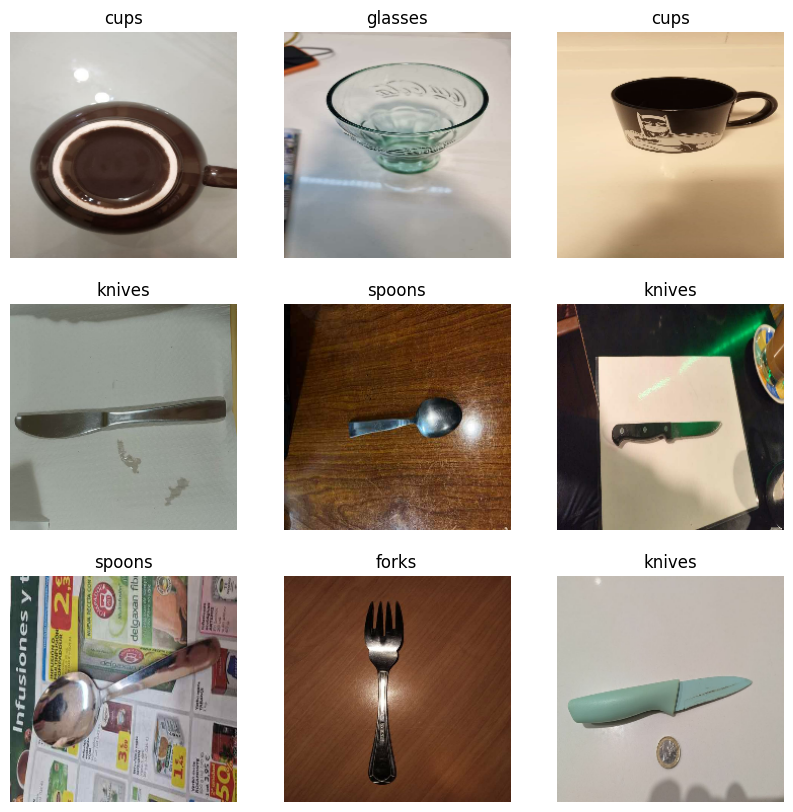

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

Arquitectura

In [ ]:
import tensorflow as tf

class SparseF1Score(tf.keras.metrics.F1Score):
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.int32) # tipo int32
        y_true = tf.reshape(y_true, [-1]) # aplanar a 1D
        num_classes = tf.shape(y_pred)[-1] # número de clases desde y_pred
        y_true_one_hot = tf.one_hot(y_true, depth=num_classes) # convertir a One-Hot
        return super().update_state(y_true_one_hot, y_pred, sample_weight) # pasar los datos al F1Score original

In [ ]:
class BaselineCNN():
  def __init__(self, input_shape, num_classes):
    self.model = Sequential()
    self.model.add(layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)))
    self.model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    self.model.add(layers.BatchNormalization())
    self.model.add(layers.MaxPooling2D((2, 2)))

    self.model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    self.model.add(layers.BatchNormalization())
    self.model.add(layers.MaxPooling2D((2, 2)))

    self.model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    self.model.add(layers.BatchNormalization())
    self.model.add(layers.MaxPooling2D((2, 2)))
    self.model.add(layers.Dropout(dropout_rate))

    self.model.add(layers.Flatten())
    self.model.add(layers.Dense(256, activation='relu'))
    self.model.add(layers.Dense(num_classes, activation='softmax'))

    self.model.summary()

  def train(self):
    self.model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
      loss=tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics=['accuracy', SparseF1Score(average='weighted', name='f1_score')]
    )

  def fit_model(self):
    self.history = self.model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs
    )

  def plots(self):
    acc = self.history.history['accuracy']
    val_acc = self.history.history['val_accuracy']

    loss = self.history.history['loss']
    val_loss = self.history.history['val_loss']

    epochs_range = range(epochs)

    plt.figure(figsize=(8, 8))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.grid(True)

  def get_predictions(self, dataset):
      y_true, y_pred, images_list = [], [], []
      for images, labels in dataset:
          preds = self.model.predict(images, verbose=0)
          y_pred.extend(np.argmax(preds, axis=1))
          y_true.extend(labels.numpy())
          images_list.extend(images.numpy())
      return np.array(y_true), np.array(y_pred), np.array(images_list)

  def plot_confusion_matrix(self, y_true, y_pred, class_names):
      cm = confusion_matrix(y_true, y_pred)
      cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

      fig, ax = plt.subplots(figsize=(8, 6))

      sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                  xticklabels=class_names, yticklabels=class_names, ax=ax)
      ax.set_title('Confusion Matrix (normalized)')
      ax.set_ylabel('True label')
      ax.set_xlabel('Predicted label')

      plt.tight_layout()
      plt.savefig('confusion_matrix.png', dpi=120)
      plt.show()


  def plot_misclassified(self, y_true, y_pred, images, class_names, n=12):
      wrong_idx = np.where(y_true != y_pred)[0]
      print(f'Total mal clasificadas: {len(wrong_idx)} / {len(y_true)}')

      show = wrong_idx[:n]
      cols = 4
      rows = int(np.ceil(len(show) / cols))

      fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
      axes = axes.flatten()

      for i, idx in enumerate(show):
          img = images[idx].astype('uint8')
          axes[i].imshow(img)
          axes[i].set_title(
              f'True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}',
              color='red', fontsize=10)
          axes[i].axis('off')

      for j in range(i + 1, len(axes)):
          axes[j].axis('off')

      plt.suptitle(f'Imágenes mal clasificadas', fontsize=13)
      plt.tight_layout()
      plt.savefig(f'misclassified.png', dpi=120)
      plt.show()

  def evaluate(self):
      print("\n── Evaluación en Test ──")
      ts = test_ds
      results = self.model.evaluate(ts, verbose=1)
      for name, val in zip(self.model.metrics_names, results):
          print(f"  {name}: {val:.4f}")



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,786,054 (98.37 MB)

 Trainable params: 25,785,606 (98.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 158s 5s/step - accuracy: 0.2814 - f1_score: 0.2807 - loss: 19.2287 - val_accuracy: 0.1458 - val_f1_score: 0.0371 - val_loss: 14.4134
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.4892 - f1_score: 0.4903 - loss: 2.6768 - val_accuracy: 0.1458 - val_f1_score: 0.0371 - val_loss: 41.6745
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.5866 - f1_score: 0.5818 - loss: 1.3455 - val_accuracy: 0.1458 - val_f1_score: 0.0375 - val_loss: 49.7962
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.7056 - f1_score: 0.7031 - loss: 0.9050 - val_accuracy: 0.1667 - val_f1_score: 0.0701 - val_loss: 57.9440
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.7771 - f1_score: 0.7752 - loss: 0.6283 - val_accuracy: 0.1771 - val_f1_score: 0.0889 - val_loss: 52.4544
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.8225 - f1_score: 0.8217 - loss: 0.5829 - val_accuracy: 0.1979 - val_f1_score: 0.11

NameError: name 'sns' is not defined

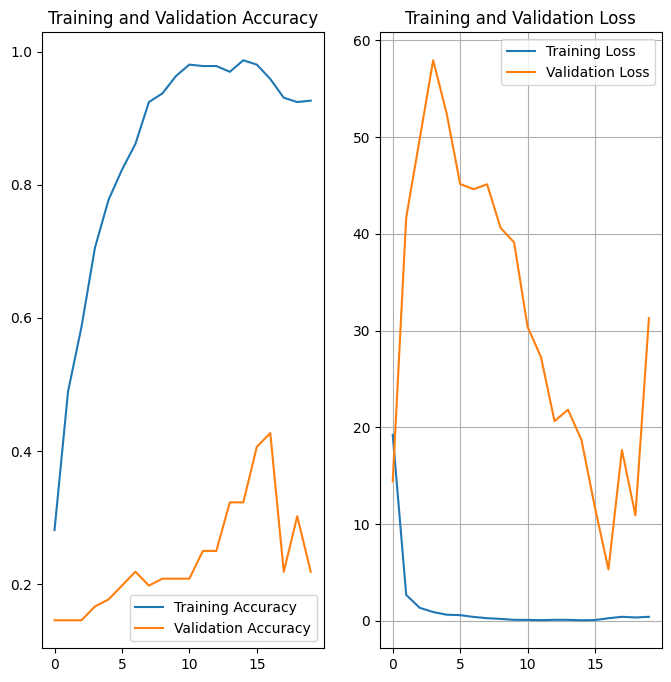

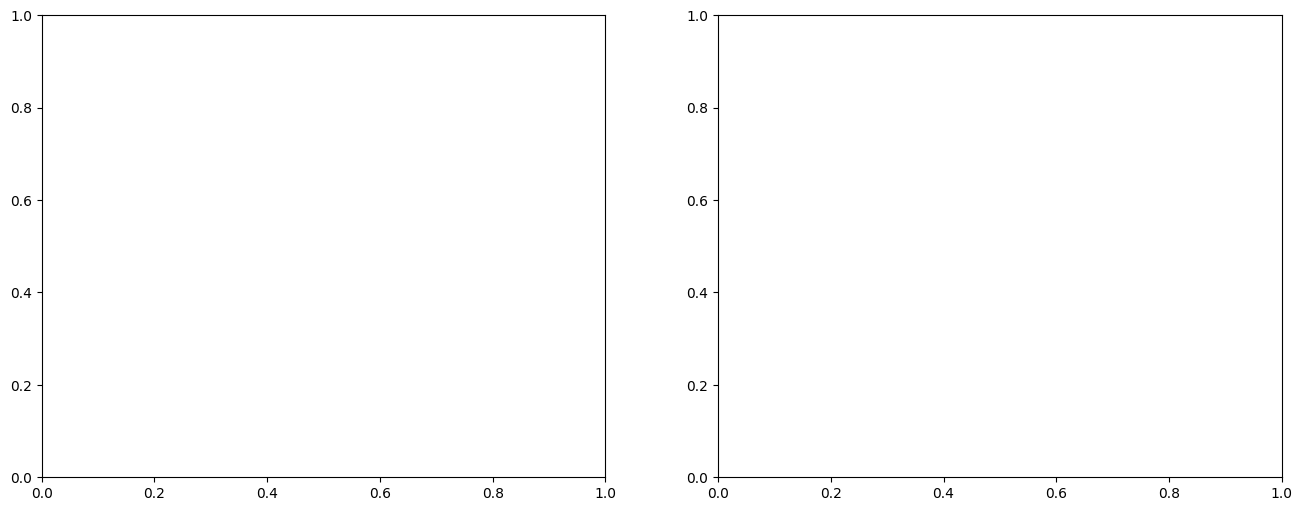

In [ ]:
if __name__ == '__main__':
    model = BaselineCNN(input_shape=(224, 224, 3), num_classes=num_classes)
    model.train()
    model.fit_model()
    model.plots()
    model.evaluate()
    y_true, y_pred, images_arr = model.get_predictions(test_ds)
    model.plot_confusion_matrix(y_true, y_pred, class_names)
    model.plot_misclassified(y_true, y_pred, images_arr, class_names, n=12)

In [ ]:
# import seaborn as sns
# from sklearn.metrics import confusion_matrix, classification_report

# def get_predictions(model_obj, dataset):
#     """Obtiene y_true, y_pred e imágenes del dataset."""
#     y_true, y_pred, images_list = [], [], []
#     for images, labels in dataset:
#         preds = model_obj.model.predict(images, verbose=0)
#         y_pred.extend(np.argmax(preds, axis=1))
#         y_true.extend(labels.numpy())
#         images_list.extend(images.numpy())
#     return np.array(y_true), np.array(y_pred), np.array(images_list)


# def plot_confusion_matrix(y_true, y_pred, class_names):
#     cm = confusion_matrix(y_true, y_pred)
#     cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # normalizada

#     fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#     # Absoluta
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#                 xticklabels=class_names, yticklabels=class_names, ax=axes[0])
#     axes[0].set_title('Confusion Matrix (counts)')
#     axes[0].set_ylabel('True label')
#     axes[0].set_xlabel('Predicted label')

#     # Normalizada
#     sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
#                 xticklabels=class_names, yticklabels=class_names, ax=axes[1])
#     axes[1].set_title('Confusion Matrix (normalized)')
#     axes[1].set_ylabel('True label')
#     axes[1].set_xlabel('Predicted label')

#     plt.suptitle(f'Dataset: {DATASET}', fontsize=13)
#     plt.tight_layout()
#     plt.savefig(f'confusion_matrix_{DATASET}.png', dpi=120)
#     plt.show()

#     # Reporte completo
#     print('\nClassification Report:')
#     print(classification_report(y_true, y_pred, target_names=class_names))


# def plot_misclassified(y_true, y_pred, images, class_names, n=12):
#     """Muestra imágenes mal clasificadas con true/pred label."""
#     wrong_idx = np.where(y_true != y_pred)[0]
#     print(f'Total mal clasificadas: {len(wrong_idx)} / {len(y_true)}')

#     if len(wrong_idx) == 0:
#         print('¡Sin errores!')
#         return

#     # Muestra hasta n ejemplos
#     show = wrong_idx[:n]
#     cols = 4
#     rows = int(np.ceil(len(show) / cols))

#     fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
#     axes = axes.flatten()

#     for i, idx in enumerate(show):
#         img = images[idx].astype('uint8')
#         axes[i].imshow(img)
#         axes[i].set_title(
#             f'True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}',
#             color='red', fontsize=10)
#         axes[i].axis('off')

#     # Oculta ejes vacíos
#     for j in range(i + 1, len(axes)):
#         axes[j].axis('off')

#     plt.suptitle(f'Imágenes mal clasificadas — {DATASET}', fontsize=13)
#     plt.tight_layout()
#     plt.savefig(f'misclassified_{DATASET}.png', dpi=120)
#     plt.show()


# # ── Ejecutar sobre TEST ────────────────────────────────────────────────────────
# print('Obteniendo predicciones sobre test set...')
# y_true, y_pred, images_arr = get_predictions(model, test_ds)

# plot_confusion_matrix(y_true, y_pred, class_names)
# plot_misclassified(y_true, y_pred, images_arr, class_names, n=12)